# Roller Coaster Data Analysis

In this project, I analyze roller coaster rankings and statistics using data visualization techniques. The goal is to uncover trends in rankings, coaster performance, and design characteristics.

## Objectives:
- Analyze ranking trends over time
- Compare roller coasters
- Explore coaster statistics (height, speed, inversions)
- Visualize distributions and relationships

## Project Code

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# Checking if Image folder exist
os.makedirs('../Images', exist_ok=True)

In [3]:
# Load Datasets
wood = pd.read_csv('Data/Golden_Ticket_Award_Winners_Wood.csv')
steel = pd.read_csv('Data/Golden_Ticket_Award_Winners_Steel.csv')
coaster_df = pd.read_csv('Data/roller_coasters.csv')

In [4]:
# Preview the Data
print(wood.head())
print(steel.head())
print(coaster_df.head())

   Rank          Name                       Park             Location  \
0     1  Boulder Dash             Lake Compounce       Bristol, Conn.   
1     2       El Toro  Six Flags Great Adventure        Jackson, N.J.   
2     3       Phoenix  Knoebels Amusement Resort        Elysburg, Pa.   
3     4    The Voyage              Holiday World    Santa Claus, Ind.   
4     5   Thunderhead                  Dollywood  Pigeon Forge, Tenn.   

           Supplier  Year Built  Points  Year of Rank  
0               CCI        2000    1333          2013  
1           Intamin        2006    1302          2013  
2  Dinn/PTC-Schmeck        1985    1088          2013  
3     Gravity Group        2006    1086          2013  
4              GCII        2004     923          2013  
   Rank                Name                        Park           Location  \
0     1    Millennium Force                 Cedar Point     Sandusky, Ohio   
1     2             Bizarro       Six Flags New England      Agawam, 

In [5]:
# Number of Rows for Wood & Steel
print(len(wood))
print(len(steel))

180
180


In [6]:
# Number of Unique Supplier Values
print(wood['Supplier'].nunique())
print(steel['Supplier'].nunique())

32
15


In [7]:
# Frequency of values for Wood & Steel
print(wood['Year of Rank'].value_counts())
print(steel['Year of Rank'].value_counts())

Year of Rank
2016    50
2017    50
2018    50
2013    10
2014    10
2015    10
Name: count, dtype: int64
Year of Rank
2016    50
2017    50
2018    50
2013    10
2014    10
2015    10
Name: count, dtype: int64


In [8]:
# Ranking over Time Function
def plot_coaster_ranking(coaster_name, park_name, df):
    coaster = df[(df['Name'] == coaster_name) & (df['Park'] == park_name)]
    
    plt.plot(coaster['Year of Rank'], coaster['Rank'], marker='o')
    plt.gca().invert_yaxis()
    
    plt.title(f"{coaster_name} Ranking Over Time")
    plt.xlabel("Year")
    plt.ylabel("Rank")

    # ---- SAVE TO IMAGE FOLDER ----
    folder = "Image"
    os.makedirs(folder, exist_ok=True)  # creates folder if it doesn't exist

    filename = f"{coaster_name}_{park_name}_ranking.png".replace(" ", "_")
    filepath = os.path.join(folder, filename)

    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()

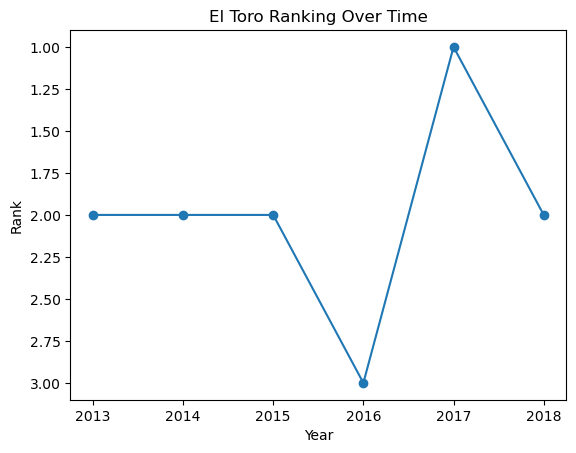

In [9]:
# Calling for El Toro ride at Six Flags on Wood
plot_coaster_ranking("El Toro", "Six Flags Great Adventure", wood)

In [10]:
# Comparing two Coasters
def compare_coasters(name1, park1, name2, park2, df):
    c1 = df[(df['Name'] == name1) & (df['Park'] == park1)]
    c2 = df[(df['Name'] == name2) & (df['Park'] == park2)]

    plt.plot(c1['Year of Rank'], c1['Rank'], label=name1)
    plt.plot(c2['Year of Rank'], c2['Rank'], label=name2)

    plt.gca().invert_yaxis()

    plt.title("Coaster Ranking Comparison")
    plt.xlabel("Year")
    plt.ylabel("Rank")
    plt.legend()

    # Save Figure to Folder
    folder = "Image"
    os.makedirs(folder, exist_ok=True) 

    filename = f"{name1}_vs_{name2}.png".replace(" ", "_")
    filepath = os.path.join(folder, filename)

    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()

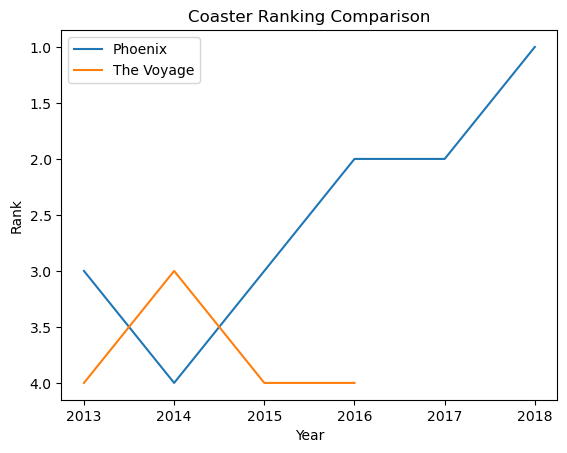

In [11]:
# Calling Coaster Ranking Comparison
compare_coasters("Phoenix", "Knoebels Amusement Resort", "The Voyage", "Holiday World", wood)

In [12]:
# Top N Coaster
def plot_top_n(n, df):
    top_n = df[df['Rank'] <= n]
    
    for coaster in top_n['Name'].unique():
        subset = top_n[top_n['Name'] == coaster]
        plt.plot(subset['Year of Rank'], subset['Rank'], label=coaster)
    
    plt.gca().invert_yaxis()
    plt.title(f"Top {n} Coasters Over Time")
    plt.xlabel("Year")
    plt.ylabel("Rank")
    plt.legend()

    # Save to Image Folder
    folder = "Image"
    os.makedirs(folder, exist_ok=True)

    filepath = os.path.join(folder, f"top_{n}_coasters.png")

    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

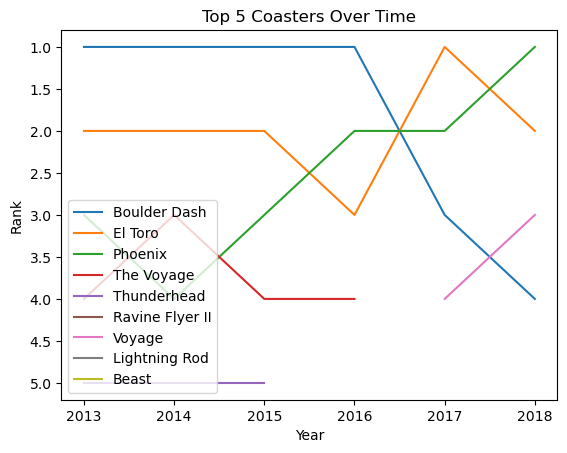

In [13]:
# Calling Top Coaster
plot_top_n(5, wood)

In [14]:
# Histogram Function
def plot_histogram(df, column):
    data = df[column].dropna()
    
    plt.hist(data, bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    # Save to Image Folder
    folder = "Image"
    os.makedirs(folder, exist_ok=True)

    filename = f"{column}_histogram.png".replace(" ", "_")
    filepath = os.path.join(folder, filename)

    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

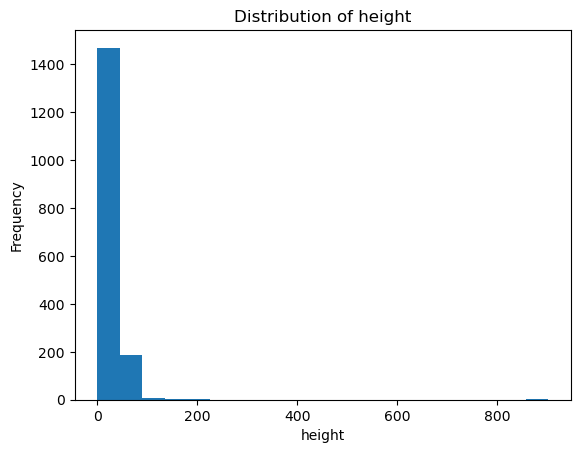

In [15]:
# Calling Distribution of Coaster Heights
plot_histogram(coaster_df, 'height')

In [16]:
# Bar Chart Inversion per Park
def inversions_by_park(df, park_name):
    park = df[df['park'] == park_name]
    park = park.sort_values('num_inversions', ascending=False)
    
    plt.bar(park['name'], park['num_inversions'])
    plt.xticks(rotation=90)
    
    plt.title(f"Inversions at {park_name}")
    plt.xlabel("Coaster")
    plt.ylabel("Inversions")

    # Save to Image Folder
    folder = "Image"
    os.makedirs(folder, exist_ok=True)

    filename = f"{park_name}_inversions.png".replace(" ", "_")
    filepath = os.path.join(folder, filename)

    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

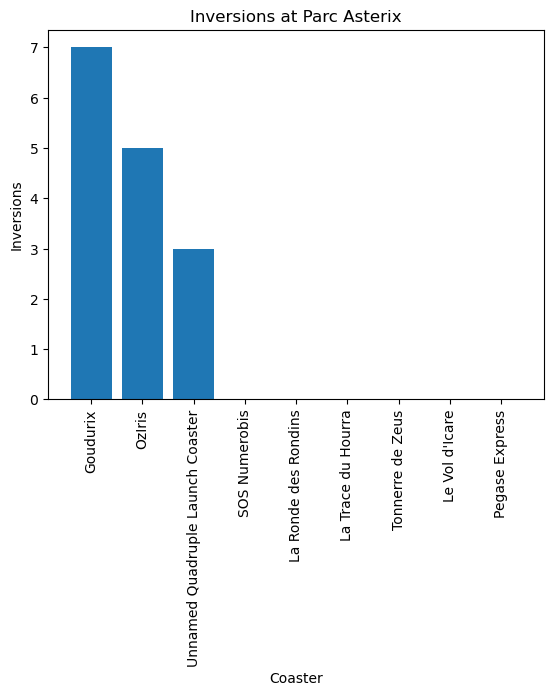

In [17]:
# Calling Inversions at Parc Asterix
inversions_by_park(coaster_df, "Parc Asterix")

In [18]:
# Pie Chart (Operating vs Closed)
def operating_vs_closed(df):
    operating = df[df['status'] == 'status.operating']
    closed = df[df['status'] == 'status.closed.definitely']
    
    counts = [len(operating), len(closed)]
    
    plt.pie(counts, labels=['Operating', 'Closed'], autopct='%0.1f%%')
    plt.title("Operating vs Closed Coasters")

    # Save to Image Folder
    folder = "Image"
    os.makedirs(folder, exist_ok=True)

    filepath = os.path.join(folder, "operating_vs_closed.png")

    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

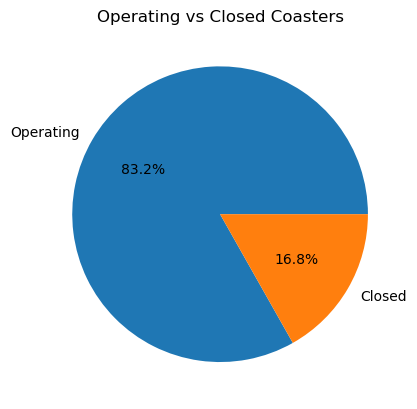

In [19]:
# Operating vs Closed Coasters
operating_vs_closed(coaster_df)

In [20]:
# Scatter Plot
def scatter_plot(df, col1, col2):
    data = df[[col1, col2]].dropna()
    
    plt.scatter(data[col1], data[col2])
    
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs {col2}")

    # Save to Image Folder
    folder = "Image"
    os.makedirs(folder, exist_ok=True)

    filename = f"{col1}_vs_{col2}_scatter.png".replace(" ", "_")
    filepath = os.path.join(folder, filename)

    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

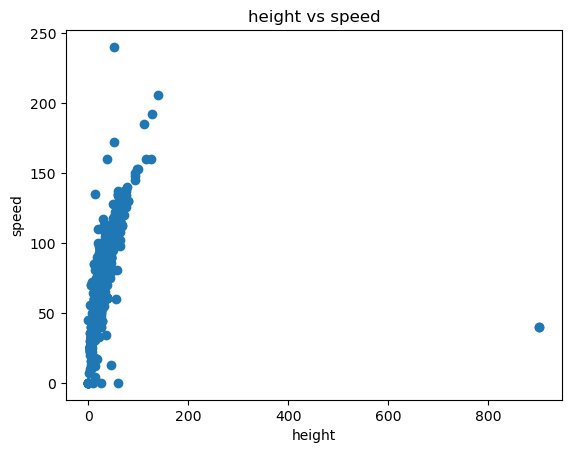

In [21]:
# Calling Height vs Speed
scatter_plot(coaster_df, "height", "speed")

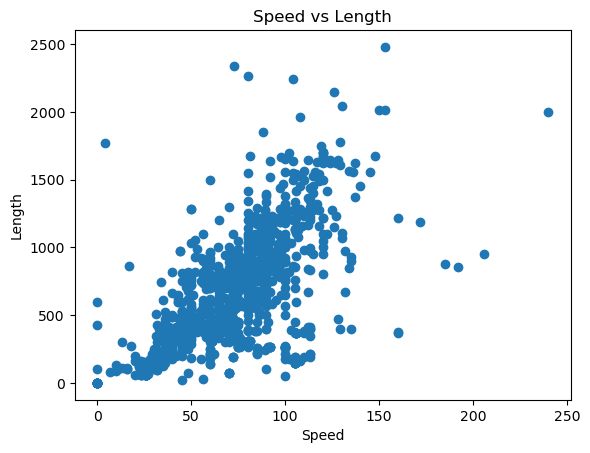

In [22]:
# Plotting Speed vs Length
plt.scatter(coaster_df['speed'], coaster_df['length'])
plt.title("Speed vs Length")
plt.xlabel("Speed")
plt.ylabel("Length")

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "speed_vs_length.png")

plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

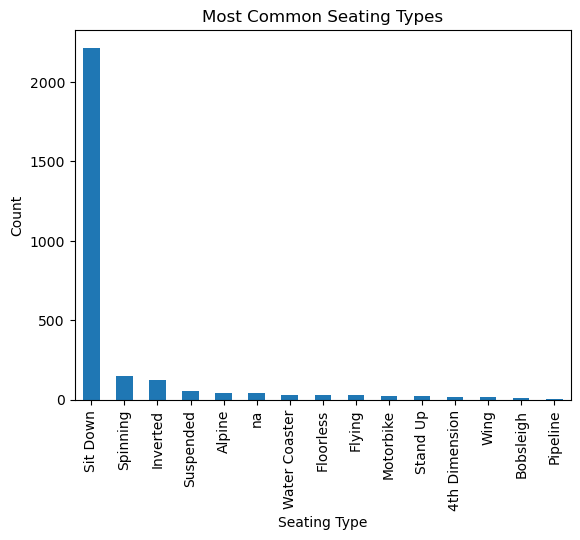

In [23]:
# Plot Common Seating Types
coaster_df['seating_type'].value_counts().plot(kind='bar')
plt.title("Most Common Seating Types")
plt.xlabel("Seating Type")
plt.ylabel("Count")

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "most_common_seating_types.png")

plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

## Datasets Used

* **Golden Ticket Awards (Wood & Steel)**
  Annual rankings of top roller coasters worldwide (2013–2018)

* **Captain Coaster Dataset**
  Comprehensive dataset of roller coaster specifications including:

  * Speed
  * Height
  * Length
  * Number of inversions
  * Manufacturer
  * Operating status

## Technologies Used

* Python
* Pandas
* Matplotlib
* Jupyter Notebook

## 📈 Key Visualizations

### 1. Ranking Trends Over Time

Tracks how individual roller coasters perform across multiple years.

### 2. Coaster Comparisons

Side-by-side comparison of two roller coasters’ rankings.

### 3. Top N Coasters Analysis

Visualizes how top-ranked coasters evolve over time.

### 4. Distribution Analysis

Histograms used to explore:

* Height distribution
* Speed distribution
* Inversion counts

### 5. Park-Level Insights

Bar charts showing inversion counts per coaster within a park.

### 6. Operational Status

Pie chart comparing operating vs closed roller coasters.

### 7. Feature Relationships

Scatter plots analyzing relationships such as:

* Height vs Speed
* Speed vs Length

## Key Insights

* Top-ranked roller coasters tend to maintain strong performance over multiple years.
* There is a positive correlation between coaster height and speed.
* Most roller coasters have relatively few inversions, with a small number of extreme outliers.
* A significant portion of coasters are no longer operating, highlighting industry turnover.

## Data Cleaning Notes

* Missing values were removed using `.dropna()`
* Outliers (e.g., extremely tall coasters) were filtered to improve visualization clarity
* Duplicate coaster names were handled by filtering by both name and park

## How to Run This Project

1. Clone the repository:

```bash
git clone https://github.com/yourusername/roller-coaster-analysis.git
cd roller-coaster-analysis
```

2. Install dependencies:

```bash
pip install -r requirements.txt
```

3. Launch Jupyter Notebook:

```bash
jupyter notebook
```

4. Open:

```
notebook/roller_coaster_analysis.ipynb
```

## Project Structure

```
roller-coaster-analysis/
│
├── data/               # Raw datasets
├── notebook/           # Jupyter notebook
├── images/             # Saved visualizations
├── src/                # Reusable functions (optional)
├── requirements.txt
└── README.md
```

## Future Improvements

* Add Seaborn/Plotly for advanced visualizations
* Build an interactive dashboard
* Perform deeper statistical analysis (correlation matrix, regression)
* Analyze manufacturer trends and specialization

## What This Project Demonstrates

* Data cleaning and preprocessing
* Exploratory Data Analysis (EDA)
* Data visualization best practices
* Writing reusable Python functions
* Structuring a professional data science project

## Contact

If you’d like to connect or discuss this project, feel free to reach out!